**Revisão de código**

Olá! Meu nome é Alan e estou feliz em revisar seu projeto hoje!

Quando eu identificar um erro pela primeira vez, apenas o apontarei. A ideia é que você tente identificá-lo e corrigi-lo por conta própria. Ao longo da revisão, também farei observações sobre possíveis melhorias no código e compartilharei comentários sobre seu entendimento do tema. Caso encontre dificuldades para resolver algum ponto, na próxima iteração fornecerei dicas mais específicas e exemplos práticos para ajudá-lo. Também estarei aberto a feedback e discussões sobre os assuntos abordados.

Você poderá encontrar meus comentários em caixas verdes, amarelas ou vermelhas, como estas:

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>
Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>
Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário: </b> <a class="tocSkip"></a>
O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno </b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-danger">
<b>Comentário geral:</b> <a class="tocSkip"></a>

Olá, Pedro Leonardo! Obrigado pelo envio. A documentação do notebook é o seu ponto mais forte: cada tabela tem inspeção, correção, enriquecimento e um resumo escrito, e cada gráfico vem acompanhado da leitura correspondente. Esse hábito de fechar toda seção com conclusão em texto é o que transforma um notebook em relatório.

Vários pontos estão bem resolvidos. Os tipos de data foram convertidos com formato explícito; a coluna <code>city</code> foi separada em cidade e área metropolitana, o que depois viabiliza o segundo teste; os excedentes usam <code>clip(lower=0)</code>, que é a forma correta de garantir que consumo abaixo do pacote não vire desconto; e a análise de dispersão vai além da variância, trazendo o coeficiente de variação — que é o que permite comparar dispersões de grandezas com escalas diferentes.

<b>O projeto ainda não pode ser aceito</b>, por dois pontos:

1. <b>O arredondamento da cobrança não foi aplicado.</b> A Megaline arredonda cada chamada para o minuto inteiro seguinte, e o consumo mensal de dados para o gigabyte inteiro seguinte. O notebook soma os valores como estão, então a receita calculada fica sistematicamente <b>abaixo</b> da real, nas duas frentes.
2. <b>O teste t foi rodado supondo variâncias iguais.</b> A justificativa está escrita na conclusão geral, mas ela se apoia na semelhança do <b>consumo</b> — e o que está sendo testado é a <b>receita</b>, cujas variâncias você mesmo mediu e são muito diferentes: 2.885,72 no Surf contra 115,81 no Ultimate.

Adianto que <b>nenhuma das duas correções inverte as suas conclusões</b> — as receitas continuarão diferentes entre os planos e o Surf continuará gerando mais receita adicional. Mas as duas mudam os números, e a segunda muda o método.

Deixei também quatro observações menores. Comentei cada seção abaixo, e fico no aguardo da próxima versão.
</div>

<div class="alert alert-block alert-success">
<b>Comentário geral (iteração 2):</b> <a class="tocSkip"></a>

Olá, Pedro Leonardo! O projeto está <b>aprovado</b>.

Os dois pontos que bloqueavam foram resolvidos, e você ainda respondeu a todas as observações menores — incluindo as que eram só sugestão. As caixas azuis explicando o que mudou em cada trecho facilitaram muito a conferência, e são uma boa prática de trabalho: quem revisa não precisa adivinhar o que foi mexido.

<b>Os arredondamentos entraram, e cada um na regra certa.</b> As chamadas são arredondadas <b>uma a uma</b>, antes da agregação; os dados são somados no mês e só então o excedente é arredondado para o gigabyte inteiro. São regras diferentes, e você aplicou a diferença corretamente.

<b>O efeito apareceu exatamente onde deveria</b>, e o padrão é revelador:

<pre>
                    antes      agora     variação
Surf   — média      57,29      60,71      +6,0%
Ultimate — média    72,11      72,31      +0,3%
</pre>

A correção mexeu vinte vezes mais no Surf do que no Ultimate. Faz sentido: o arredondamento só cobra quando há excedente, e quem excede o pacote é o usuário do Surf. O Ultimate quase não sai dos 70 dólares, então quase não havia o que arredondar. Se a variação tivesse vindo igual nos dois planos, seria sinal de que algo estava errado.

<b>E o teste passou para a versão de Welch</b>, nos dois casos, com a justificativa reescrita: agora ela se apoia na variância da <b>receita</b> — 3.065,88 no Surf contra 129,67 no Ultimate —, que é a grandeza de fato testada.

<b>Além disso, você fez as três coisas que eu tinha deixado como sugestão:</b> os números do texto passaram a sair por f-string, a receita acumulada por plano foi calculada, e a conclusão geral agora traz os dois valores-p, a ressalva sobre a força da evidência no segundo teste e a limitação da independência das observações.

Deixei quatro comentários adiante. Três confirmam as correções e um traz uma observação sobre células antigas que ficaram no arquivo. Nenhuma pendência.

Parabéns pelo trabalho.
</div>

# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]

## Inicialização

In [66]:
# Carregando todas as bibliotecas
import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt


## Carregue os dados

In [67]:
# Carregue os arquivos de dados em diferentes DataFrames
df_calls = pd.read_csv('/datasets/megaline_calls.csv')
df_internet = pd.read_csv('/datasets/megaline_internet.csv')
df_messages = pd.read_csv('/datasets/megaline_messages.csv')
df_plans = pd.read_csv('/datasets/megaline_plans.csv')
df_users = pd.read_csv('/datasets/megaline_users.csv')

## Prepare os dados

## Planos

In [68]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
print(df_plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None



* df_plans contém 8 colunas e duas linhas
* não há nenhum valor explicitamente nulo ou ausente
* cabeçalho contém nomes coerente e não precisa de correção
* os tipos de variáveis parecem adequados aos valores que elas representam


In [69]:

# Imprima uma amostra de dados dos planos
print(df_plans.head())


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


df_plans é uma tabela simples e coerente que apresenta as características dos planos disponibilizados e não precisa de ajustes.
Suas características são:

* contém 8 colunas e 2 linhas
* não há nenhum valor explicitamente nulo ou ausente
* não há valor duplicado
* cabeçalho contém nomes coerente e não precisa de correção
* os tipos de variáveis parecem adequados aos valores que elas representam


## Corrija os dados

Até o presente momento, não foram encontrados dados que precisacem ser corrigidos.

## Enriqueça os dados

Até o presente momento, não foi concebida necessidade de enriquecimento dos dados do df_plans.

## Usuários

In [70]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
print(df_users.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


* contém 8 colunas e 500 linhas
* cabeçalho contém nomes coerente e não precisa de correção
* os tipos de variáveis das colunas 'reg_date' e ' churn_date' precisam ser avaliados se seus tipos estão o mais coerente com o contexto da tabela.
* aparentemente, não há nenhum valor explicitamente nulo, mas é necessário investigar a coluna 'churn_date' para entender se os valores ausentes estão dentro do contexto esperado.
* é necessário investigar a presença de dados duplicados

In [71]:
# Imprima uma amostra de dados dos usuários
print(df_users.head(5))

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


In [72]:
# Encontrando linhas não nulas na coluna 'churn_date' para avaliação
df_users_churn = df_users[~df_users['churn_date'].isna()]
print(df_users_churn.head(1))

   user_id first_name last_name  age                                    city  \
6     1006     Jesusa  Bradford   73  San Francisco-Oakland-Berkeley, CA MSA   

     reg_date      plan  churn_date  
6  2018-11-27  ultimate  2018-12-18  


* os tipos de variáveis das colunas 'reg_date' e ' churn_date' precisam ajustar seus tipos para datetime no intuito de facilitar a manipulação dos dados
* é possível aprimorar estas colunas de datas separando por seus componentes dia, mês e ano
* o conteúdo da coluna 'city' está mais extenso do que o que se propõe, é
* é possível aprimorar esta coluna dividindo em duas partes, uma com a MSA (Metropolitan Statistical Area) que ela abrange e a outra com o nome das cidades desta 'área estatística metropolitana'

##### RESUMO DA TABELA df_users

df_users é uma tabela que apresenta a amostra dos clientes que serão estudados.
Suas características básicas são:
* contém 8 colunas e 500 linhas
* cabeçalho contém nomes coerente e não precisa de correção
* aparentemente, não há nenhum valor explicitamente nulo, a coluna 'churn_date' contém valores ausentes, mas estão dentro do contexto esperado.

Ela precisa das seguintes intervenções:
* os tipos de variáveis das colunas 'reg_date' e ' churn_date' precisam ajustar seus tipos para datetime no intuito de facilitar a manipulação dos dados
* é necessário investigar a presença de dados duplicados

Ela deve ser aprimorada da seguinte forma:
* o conteúdo da coluna 'city' está mais extenso do que o que se propõe, é possível aprimorar esta coluna dividindo em duas partes, uma com a MSA (Metropolitan Statistical Area) que ela abrange e a outra com o nome das cidades desta 'área estatística metropolitana
* as colunas 'reg_date' e ' churn_date' terão suas datas separando por seus componentes dia, mês e ano
* os valores ausentes serão substituídos por 0

### Corrija os dados

In [73]:
# ajustando as colunas 'reg_date' e 'churn_date' para datetime
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], format='%Y-%m-%d')

print(df_users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None


* coluna 'reg_date' e 'churn_date' que contém conteúdo de data foram modificadas para o tipo datetime

In [74]:
# Investigando valores duplicados
print('Quantidade de linhas explicitamente duplicadas:', df_users.duplicated().sum())

Quantidade de linhas explicitamente duplicadas: 0


* não foram encontradas linhas duplicadas

### Enriqueça os dados

In [75]:
# dividindo a coluna 'city' em 'city_msa' e 'state_msa'
df_users[['city_msa','state_msa']] = df_users['city'].str.split(',', n=1, expand=True)

# limpando espaços em branco e removendo o sufixo 'MSA'
df_users['state_msa'] = df_users['state_msa'].str.strip()
df_users['state_msa'] = df_users['state_msa'].str.replace('MSA', '', regex=False).str.strip()

# apagando a coluna original 'city'
df_users = df_users.drop(columns='city')

In [76]:
# separando os componentes das colunas 'reg_date' e ' churn_date' em dia, mês e ano

# trabalhando na coluna 'reg_date'
df_users['reg_day'] = df_users['reg_date'].dt.day 
df_users['reg_month'] = df_users['reg_date'].dt.month 
df_users['reg_year'] = df_users['reg_date'].dt.year

df_users = df_users.drop(columns='reg_date')              # apagando a coluna 'reg_date' original

# trabalhando na coluna 'churn_date'
df_users['churn_day'] = df_users['churn_date'].dt.day 
df_users['churn_month'] = df_users['churn_date'].dt.month 
df_users['churn_year'] = df_users['churn_date'].dt.year

df_users = df_users.drop(columns='churn_date')              # apagando a coluna 'churn_date' original

# imprimindo para garantir que o objetivo foi alcançado
print(df_users.head())

   user_id first_name  last_name  age      plan  \
0     1000   Anamaria      Bauer   45  ultimate   
1     1001     Mickey  Wilkerson   28      surf   
2     1002     Carlee    Hoffman   36      surf   
3     1003   Reynaldo    Jenkins   52      surf   
4     1004    Leonila   Thompson   40      surf   

                        city_msa state_msa  reg_day  reg_month  reg_year  \
0  Atlanta-Sandy Springs-Roswell        GA       24         12      2018   
1        Seattle-Tacoma-Bellevue        WA       13          8      2018   
2   Las Vegas-Henderson-Paradise        NV       21         10      2018   
3                          Tulsa        OK       28          1      2018   
4        Seattle-Tacoma-Bellevue        WA       23          5      2018   

   churn_day  churn_month  churn_year  
0        NaN          NaN         NaN  
1        NaN          NaN         NaN  
2        NaN          NaN         NaN  
3        NaN          NaN         NaN  
4        NaN          NaN         Na

In [77]:
# substituindo os valores ausentes por 0
df_users['churn_day'] = df_users['churn_day'].fillna(0).astype(int)
df_users['churn_month'] = df_users['churn_month'].fillna(0).astype(int)
df_users['churn_year'] = df_users['churn_year'].fillna(0).astype(int)

print(df_users.head())


   user_id first_name  last_name  age      plan  \
0     1000   Anamaria      Bauer   45  ultimate   
1     1001     Mickey  Wilkerson   28      surf   
2     1002     Carlee    Hoffman   36      surf   
3     1003   Reynaldo    Jenkins   52      surf   
4     1004    Leonila   Thompson   40      surf   

                        city_msa state_msa  reg_day  reg_month  reg_year  \
0  Atlanta-Sandy Springs-Roswell        GA       24         12      2018   
1        Seattle-Tacoma-Bellevue        WA       13          8      2018   
2   Las Vegas-Henderson-Paradise        NV       21         10      2018   
3                          Tulsa        OK       28          1      2018   
4        Seattle-Tacoma-Bellevue        WA       23          5      2018   

   churn_day  churn_month  churn_year  
0          0            0           0  
1          0            0           0  
2          0            0           0  
3          0            0           0  
4          0            0           


* a coluna 'city' foi dividida e substituída pelas seguintes colunas:

- 'city_msa' que contém o nome explícito das cidades da MSA;

- 'state_msa' que contém o estado da MSA


* as colunas com datas tiveram seus componentes separados em dia, mês e ano 

<div class="alert alert-block alert-success">
<b>Comentário — enriquecimento da tabela de usuários:</b> <a class="tocSkip"></a>

Boa etapa, e com uma decisão que rende frutos mais adiante.

Separar a coluna <code>city</code> em cidade e área metropolitana é o que torna possível o segundo teste de hipótese, lá no final. Sem essa separação, comparar a região de NY-NJ com as demais exigiria uma busca por texto dentro do nome completo da cidade, que é frágil.

A conversão das datas com <code>format</code> explícito também é o cuidado certo: sem ele, o pandas tenta adivinhar o formato, e uma data ambígua como 03/04 pode virar março ou abril dependendo da linha.

Uma observação sobre o preenchimento com zero nas colunas derivadas de <code>churn_date</code>. Funciona para o que você precisa, mas vale saber que zero e ausente passam a ser indistinguíveis: um usuário que não cancelou fica com mês de cancelamento 0, que não é um mês. Como você não usa essa coluna nos cálculos seguintes, não há consequência — mas em análises de retenção essa distinção importa, e manter o ausente como ausente costuma ser mais seguro.
</div>

## Chamadas

In [78]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
print(df_calls.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


* contém 4 colunas e 137735 linhas
* cabeçalho contém nomes coerentes, mas a coluna 'duration' poderia especificar a unidade de medida em minutos
* aparentemente, não há nenhum valor explicitamente nulo
* é necessário investigar a presença de dados duplicados
* aparentemente, os tipos das variáveis não estão adequados, mas é necessário imprimir uma amostra para avaliar.


In [79]:
# Imprima uma amostra de dados das chamadas
print(df_calls.head())


         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


* a coluna 'call_date' precisa ter seu tipo modificado para datetime
* é possível aprimorar a coluna call_date separando por seus componentes dia, mês e ano

##### RESUMO DA TABELA df_calls

df_calls é uma tabela que apresenta os dados sobre as chamadas.
Suas características básicas são:
* contém 4 colunas e 137735 linhas
* cabeçalho contém nomes coerentes que não precisam de conserto
* aparentemente, não há nenhum valor explicitamente nulo
* os tipos das variáveis estão adequados, exceto na coluna 'call_date'. Contudo, a coluna 'duration' ficará em observação para avaliar a necessidade futura de modificar seus dados para datetime caso necessário.

Ela precisa das seguintes intervenções:
* a coluna 'call_date' precisa ter seu tipo modificado para datetime
* é necessário investigar a presença de dados duplicados

Ela deve ser aprimorada da seguinte forma:
* a coluna 'duration' deve especificar a unidade de medida em minutos
* a coluna 'call_date' terá sua data separada por seus componentes dia, mês e ano


### Corrija os dados

In [80]:
# ajustando as colunas 'call_date' para datetime
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')

print(df_calls.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None


In [81]:
# Investigando valores duplicados
print('Quantidade de linhas explicitamente duplicadas:', df_calls.duplicated().sum())


Quantidade de linhas explicitamente duplicadas: 0


### Enriqueça os dados

In [82]:
# modificar o nome da coluna 'duration' especificando o unidade de medida para 'duration_minutes'
df_calls = df_calls.rename(columns={'duration': 'duration_minutes'})

print(df_calls.head())


         id  user_id  call_date  duration_minutes
0   1000_93     1000 2018-12-27              8.52
1  1000_145     1000 2018-12-27             13.66
2  1000_247     1000 2018-12-27             14.48
3  1000_309     1000 2018-12-28              5.76
4  1000_380     1000 2018-12-30              4.22


In [83]:
# separando os componentes da coluna 'call_date' dia, mês e ano
df_calls['call_day'] = df_calls['call_date'].dt.day 
df_calls['call_month'] = df_calls['call_date'].dt.month 
df_calls['call_year'] = df_calls['call_date'].dt.year

df_calls = df_calls.drop(columns='call_date')              # apagando a coluna 'call_date' original

# imprimindo para garantir que o objetivo foi alcançado
print(df_calls.head())


         id  user_id  duration_minutes  call_day  call_month  call_year
0   1000_93     1000              8.52        27          12       2018
1  1000_145     1000             13.66        27          12       2018
2  1000_247     1000             14.48        27          12       2018
3  1000_309     1000              5.76        28          12       2018
4  1000_380     1000              4.22        30          12       2018


* a coluna call_date foi modificada para tipo datetime
* a coluna call_date teve seus componentes separados em dia, mês e ano 
* não há valores explicitamente duplicados
* o cabeçalho da coluna 'duration' foi modificado para 'duration_minutes'


<div class="alert alert-block alert-success">
<b>Comentário — tratamento das tabelas de consumo:</b> <a class="tocSkip"></a>

As quatro tabelas receberam o mesmo tratamento sistemático — informações gerais, amostra, verificação de duplicatas, conversão de data e decomposição em dia, mês e ano — e cada uma fecha com um resumo escrito.

Renomear <code>duration</code> para <code>duration_minutes</code> é uma boa prática: a unidade faz parte do significado do número, e deixá-la no nome da coluna evita erro de interpretação meses depois.

E extrair o mês em coluna própria é a decisão que estrutura toda a etapa seguinte, já que a agregação do projeto inteiro é por usuário e por mês.
</div>

## Mensagens

In [84]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
print(df_messages.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


* contém 3 colunas e 76051 linhas
* cabeçalho contém nomes coerentes que não precisam de ajuste
* aparentemente, não há nenhum valor explicitamente nulo
* é necessário investigar a presença de dados duplicados
* aparentemente, os tipos das variáveis não estão adequados, mas é necessário imprimir uma amostra para avaliar.


In [85]:
# Imprima uma amostra dos dados das mensagens
print(df_messages.head())


         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


* a coluna 'message_date' precisa ter seu tipo modificado para datetime
* é possível aprimorar a coluna message_date separando por seus componentes dia, mês e ano

#### RESUMO DA TABELA df_messages

df_messages é uma tabela que apresenta os dados sobre as mensagens de texto.
Suas características básicas são:
* contém 3 colunas e 76051 linhas
* cabeçalho contém nomes coerentes que não precisam de ajuste
* aparentemente, não há nenhum valor explicitamente nulo
* é necessário investigar a presença de dados duplicados
* os tipos das variáveis estão adequados, exceto na coluna 'message_date'.

Ela precisa das seguintes intervenções:
* a coluna 'message_date' precisa ter seu tipo modificado para datetime
* é necessário investigar a presença de dados duplicados

Ela deve ser aprimorada da seguinte forma:
* a coluna 'message_date' terá sua data separada por seus componentes dia, mês e ano


### Corrija os dados

In [86]:
# ajustando as colunas 'message_date' para datetime
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')

print(df_messages.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None


In [87]:
# Investigando valores duplicados
print('Quantidade de linhas explicitamente duplicadas:', df_messages.duplicated().sum())


Quantidade de linhas explicitamente duplicadas: 0


### Enriqueça os dados

In [88]:
# separando os componentes da coluna 'message_date' em dia, mês e ano
df_messages['message_day'] = df_messages['message_date'].dt.day 
df_messages['message_month'] = df_messages['message_date'].dt.month 
df_messages['message_year'] = df_messages['message_date'].dt.year

df_messages = df_messages.drop(columns='message_date')              # apagando a coluna 'message_date' original

# imprimindo para garantir que o objetivo foi alcançado
print(df_messages.head())


         id  user_id  message_day  message_month  message_year
0  1000_125     1000           27             12          2018
1  1000_160     1000           31             12          2018
2  1000_223     1000           31             12          2018
3  1000_251     1000           27             12          2018
4  1000_255     1000           26             12          2018


* a coluna 'message_date' foi modificada para tipo datetime
* não há valores explicitamente duplicados
* a coluna 'message_date' teve seus componentes separados em dia, mês e ano 


## Internet

In [89]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
print(df_internet.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


* contém 4 colunas e 104.825 linhas
* cabeçalho contém nomes coerentes que não precisam de ajuste
* aparentemente, não há nenhum valor explicitamente nulo
* é necessário investigar a presença de dados duplicados
* aparentemente, os tipos das variáveis não estão adequados, mas é necessário imprimir uma amostra para avaliar.


In [90]:
#  Imprima uma amostra de dados para o tráfego da internet
print(df_internet.head())


         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


* a coluna 'session_date' precisa ter seu tipo modificado para datetime
* é possível aprimorar a coluna 'session_date' separando por seus componentes dia, mês e ano


#### RESUMO DA TABELA df_internet

df_internet é uma tabela que apresenta os dados sobre as sessões web.
Suas características básicas são:
* contém 4 colunas e 104.825 linhas
* cabeçalho contém nomes coerentes que não precisam de ajuste
* aparentemente, não há nenhum valor explicitamente nulo
* é necessário investigar a presença de dados duplicados
* aparentemente, os tipos das variáveis estão adequados, exceto na coluna'session_date'.

Ela precisa das seguintes intervenções:
* a coluna 'session_date' precisa ter seu tipo modificado para datetime
* é necessário investigar a presença de dados duplicados

Ela deve ser aprimorada da seguinte forma:
* a coluna 'session_date' terá sua data separada por seus componentes dia, mês e ano


### Corrija os dados

In [91]:
# ajustando as colunas 'session_date' para datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], format='%Y-%m-%d')

print(df_internet.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None


In [92]:
# Investigando valores duplicados
print('Quantidade de linhas explicitamente duplicadas:', df_internet.duplicated().sum())


Quantidade de linhas explicitamente duplicadas: 0


### Enriqueça os dados

In [93]:
# separando os componentes da coluna 'call_date' em dia, mês e ano
df_internet['session_day'] = df_internet['session_date'].dt.day 
df_internet['session_month'] = df_internet['session_date'].dt.month 
df_internet['session_year'] = df_internet['session_date'].dt.year

df_internet = df_internet.drop(columns='session_date')              # apagando a coluna 'session_date' original

# imprimindo para garantir que o objetivo foi alcançado
print(df_internet.head())


         id  user_id  mb_used  session_day  session_month  session_year
0   1000_13     1000    89.86           29             12          2018
1  1000_204     1000     0.00           31             12          2018
2  1000_379     1000   660.40           28             12          2018
3  1000_413     1000   270.99           26             12          2018
4  1000_442     1000   880.22           27             12          2018


* a coluna 'session_date' foi modificada para tipo datetime
* não há valores explicitamente duplicados
* a coluna 'session_date' teve seus componentes separados em dia, mês e ano 


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [94]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
print(df_plans.head())


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Agregue os dados por usuário

In [95]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.

# Agregando os dados de número de chamadas feitas por cada usuário por mês
agg_num_calls = {'id': 'count'}
grp_calls = df_calls.groupby(['user_id','call_month'])
grp_calls.agg(agg_num_calls)

# Salvando em um df
df_num_calls = grp_calls.agg(agg_num_calls).reset_index().rename(columns={'id':'number_calls'})

# Criando uma coluna índice para unir df
df_num_calls['merge_key'] = df_num_calls['user_id'].astype(str) + '_' + df_num_calls['call_month'].astype(str)
print(df_num_calls)


      user_id  call_month  number_calls merge_key
0        1000          12            16   1000_12
1        1001           8            27    1001_8
2        1001           9            49    1001_9
3        1001          10            65   1001_10
4        1001          11            64   1001_11
...       ...         ...           ...       ...
2253     1498          12            39   1498_12
2254     1499           9            41    1499_9
2255     1499          10            53   1499_10
2256     1499          11            45   1499_11
2257     1499          12            65   1499_12

[2258 rows x 4 columns]


In [96]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.


<div class="alert alert-block alert-info">
<b>Realizando o arredondamento do tempo da chamada individual antes de agregar</b> <a class="tocSkip"></a>
</div>


In [97]:
# Arredondar a duração de cada chamada
df_calls['duration_minutes'] = np.ceil(df_calls['duration_minutes'])

In [98]:
# Agregando a quantidade de minutos gastos por cada usuário por mês
agg_minutes = {'duration_minutes': 'sum'}
grp_calls = df_calls.groupby(['user_id','call_month'])
minutes_calls = grp_calls.agg(agg_minutes)

# Salvando em um df
df_minutes_calls = grp_calls.agg(agg_minutes).reset_index().rename(columns={'duration_minutes':'sum_duration_minutes'})

# Criando uma coluna índice para unir df
df_minutes_calls['merge_key'] = df_minutes_calls['user_id'].astype(str) + '_' + df_minutes_calls['call_month'].astype(str)
print(df_minutes_calls)


      user_id  call_month  sum_duration_minutes merge_key
0        1000          12                 124.0   1000_12
1        1001           8                 182.0    1001_8
2        1001           9                 315.0    1001_9
3        1001          10                 393.0   1001_10
4        1001          11                 426.0   1001_11
...       ...         ...                   ...       ...
2253     1498          12                 339.0   1498_12
2254     1499           9                 346.0    1499_9
2255     1499          10                 385.0   1499_10
2256     1499          11                 308.0   1499_11
2257     1499          12                 496.0   1499_12

[2258 rows x 4 columns]


<div class="alert alert-block alert-danger">
<b>Comentário — falta arredondar cada chamada:</b> <a class="tocSkip"></a>

Este é o primeiro dos dois pontos que impedem a aprovação, e ele está aqui, na agregação dos minutos.

Volte ao enunciado do projeto e releia a regra de cobrança da Megaline: a operadora <b>arredonda para cima os segundos para minutos</b>, e faz isso <b>em cada chamada individualmente</b>. Uma ligação de 1 minuto e 5 segundos é cobrada como 2 minutos; uma de 8 segundos é cobrada como 1 minuto.

O que a célula faz é somar as durações como estão, com os decimais. O resultado é um total de minutos <b>menor</b> que o cobrável, e a diferença não é pequena: com dezenas de chamadas por mês, cada uma perdendo em média meio minuto de arredondamento, o desvio chega facilmente a 20 ou 30 minutos por usuário — que é justamente a faixa em que o excedente do plano Surf começa a ser cobrado.

<b>Repare que a ordem das operações importa, e é o ponto da tarefa.</b> Arredondar cada chamada e depois somar dá um resultado diferente de somar tudo e arredondar o total no fim. A regra da operadora é a primeira; a segunda subestima a conta.

O arredondamento precisa entrar <b>antes</b> desta agregação, aplicado à coluna de duração de cada chamada. A biblioteca <code>numpy</code>, que você já importou, tem a função que faz exatamente isso — arredondar sempre para cima, independentemente da parte decimal.

O resto da célula está correto: o agrupamento por usuário e mês e a soma são exatamente o que a tarefa pede.
</div>

<div class="alert alert-block alert-success">
<b>Comentário — o arredondamento das chamadas (iteração 2):</b> <a class="tocSkip"></a>

Resolvido, e no lugar certo — que era o ponto da tarefa.

<pre>
df_calls['duration_minutes'] = np.ceil(df_calls['duration_minutes'])   &lt;- célula anterior
grp_calls = df_calls.groupby(['user_id','call_month'])                  &lt;- agregação vem depois
</pre>

O arredondamento acontece <b>antes</b> do agrupamento, aplicado a cada chamada individual. É essa ordem que reproduz a regra da Megaline: uma ligação de 1 minuto e 5 segundos custa 2 minutos, e uma de 8 segundos custa 1 minuto inteiro.

<b>Vale ter clara a diferença que isso faz</b>, porque o erro oposto é silencioso. Arredondar o total do mês no fim daria um número menor — cada chamada perde em média meio minuto, e com dezenas de ligações mensais a diferença chega justamente à faixa em que o excedente do Surf começa a ser cobrado. Nenhuma das duas versões dá erro; só uma corresponde à conta que a operadora faz.

O resto da célula continua correto: o agrupamento por usuário e mês e a soma são o que a tarefa pede.
</div>

In [99]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

# Agregando o número de mensagens enviadas por cada usuário por mês
agg_message = {'id': 'count'}
grp_messages = df_messages.groupby(['user_id','message_month'])
number_messages = grp_messages.agg(agg_message)

# Salvando em um df
df_number_messages = grp_messages.agg(agg_message).reset_index().rename(columns={'id':'number_messages'})

# Criando uma coluna índice para unir df
df_number_messages['merge_key'] = df_number_messages['user_id'].astype(str) + '_' + df_number_messages['message_month'].astype(str)
print(df_number_messages)


      user_id  message_month  number_messages merge_key
0        1000             12               11   1000_12
1        1001              8               30    1001_8
2        1001              9               44    1001_9
3        1001             10               53   1001_10
4        1001             11               36   1001_11
...       ...            ...              ...       ...
1801     1496              9               21    1496_9
1802     1496             10               18   1496_10
1803     1496             11               13   1496_11
1804     1496             12               11   1496_12
1805     1497             12               50   1497_12

[1806 rows x 4 columns]


In [100]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.

# Agregando o volume de tráfego de internet usado por cada usuário por mês
agg_internet = {'mb_used': 'sum'}
grp_internet = df_internet.groupby(['user_id','session_month'])
mbs_used = grp_internet.agg(agg_internet)

# Salvando em um df
df_mbs_used = grp_internet.agg(agg_internet).reset_index().rename(columns={'mb_used':'sum_mb_used'})

# Criando uma coluna índice para unir df
df_mbs_used['merge_key'] = df_mbs_used['user_id'].astype(str) + '_' + df_mbs_used['session_month'].astype(str)
print(df_mbs_used)


      user_id  session_month  sum_mb_used merge_key
0        1000             12      1901.47   1000_12
1        1001              8      6919.15    1001_8
2        1001              9     13314.82    1001_9
3        1001             10     22330.49   1001_10
4        1001             11     18504.30   1001_11
...       ...            ...          ...       ...
2272     1498             12     23137.69   1498_12
2273     1499              9     12984.76    1499_9
2274     1499             10     19492.43   1499_10
2275     1499             11     16813.83   1499_11
2276     1499             12     22059.21   1499_12

[2277 rows x 4 columns]


In [101]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

# Juntando df com dados de chamadas e minutos
df_num_min = df_num_calls.merge(df_minutes_calls, on='merge_key', how='outer')
df_num_min = df_num_min.drop(columns=['user_id_x', 'user_id_y', 'call_month_x', 'call_month_y'])     # ajustando as colunas
#print(df_num_min)

# Juntando df com dados de chamadas, minutos e mensagens
df_num_min_mess = df_num_min.merge(df_number_messages, on='merge_key', how='outer')
df_num_min_mess = df_num_min_mess.drop(columns=['user_id', 'message_month'])                         
#print(df_num_min_mess)

# Juntando df com dados de chamadas, minutos, mensagens e internet
df_user_month = df_num_min_mess.merge(df_mbs_used, on='merge_key', how='outer')

# Ajustando a quantidade, tipo e ordem das colunas
df_user_month[['user_id','month_used']] = df_user_month['merge_key'].str.split('_', n=1, expand=True)
df_user_month = df_user_month.drop(columns=['session_month', 'merge_key'])
df_user_month['user_id'] = df_user_month['user_id'].astype(int)
df_user_month = df_user_month.sort_values('user_id')
df_user_month = df_user_month[['user_id', 'month_used', 'number_calls', 'sum_duration_minutes', 'number_messages', 'sum_mb_used']]

# Substituindo valores ausentes
df_user_month['number_calls'] = df_user_month['number_calls'].fillna(0).astype(int)
df_user_month['sum_duration_minutes'] = df_user_month['sum_duration_minutes'].fillna(0)
df_user_month['number_messages'] = df_user_month['number_messages'].fillna(0).astype(int)
df_user_month['sum_mb_used'] = df_user_month['sum_mb_used'].fillna(0)

print(df_user_month.tail(20))


      user_id month_used  number_calls  sum_duration_minutes  number_messages  \
2238     1496          9            52                 414.0               21   
2239     1496         10            46                 317.0               18   
2240     1496         11            39                 308.0               13   
2241     1496         12            40                 294.0               11   
2242     1497         12            54                 300.0               50   
2250     1498          9            45                 363.0                0   
2243     1498          2            37                 244.0                0   
2244     1498          3            37                 266.0                0   
2245     1498          4            47                 365.0                0   
2246     1498          5            35                 288.0                0   
2247     1498          6            37                 238.0                0   
2248     1498          7    

In [102]:
# Adicione as informações sobre o plano
# criando um df resumido de usuários
df_users_fit = df_users[['user_id', 'plan', 'reg_month', 'churn_month']]

print(df_users_fit.tail())


     user_id      plan  reg_month  churn_month
495     1495      surf          9            0
496     1496      surf          2            0
497     1497  ultimate         12            0
498     1498      surf          2            0
499     1499      surf          5            0


In [103]:
# Criando um df com o plano de cada usuário
df_users_plan = df_users_fit.merge(df_plans, 
                                   left_on='plan',
                                   right_on='plan_name').drop(columns='plan_name')


In [104]:

# Criando um df com os dados do consumo mensal e quanto é cobrado por cada produto
df_month_plan_used = df_user_month.merge(df_users_plan, on='user_id', how='outer')


# teste  de remover linhas ausentes

In [105]:
df_month_plan_used = df_month_plan_used.dropna(subset=['month_used'])

In [106]:
# Criando uma nova coluna para calcular o custo extra por mensagem excedida
df_month_plan_used['usd_message_add'] = (
    (df_month_plan_used['number_messages']
     -df_month_plan_used['messages_included']).clip(lower=0) 
    * df_month_plan_used['usd_per_message']
)


In [107]:
# Criando uma nova coluna para calcular o custo extra por minuto excedido
df_month_plan_used['usd_minute_add'] = (
    (df_month_plan_used['sum_duration_minutes']
     -df_month_plan_used['minutes_included']).clip(lower=0) 
    * df_month_plan_used['usd_per_minute']
)


<div class="alert alert-block alert-info">
<b>Convertendo o excedente para gigabytes e arredondando para cima antes de multiplicar pelo preço </b> <a class="tocSkip"></a>
</div>

In [108]:
# Criando uma coluna com o excedente
df_month_plan_used['excedente_mb'] = (
    df_month_plan_used['sum_mb_used'] - df_month_plan_used['mb_per_month_included']
).clip(lower=0)

# Arredondando o excedente para cima
df_month_plan_used['excedente_gb'] = np.ceil(df_month_plan_used['excedente_mb'] / 1024)
#print(df_month_plan_used.head())


In [109]:
# Criando uma nova coluna para calcular o custo extra por internet excedida

# Calculando o exclusivamente do custo do excedente do consumo da internet
df_month_plan_used['usd_mb_add'] = (
    df_month_plan_used['excedente_gb'] * df_month_plan_used['usd_per_gb'])

#print(df_month_plan_used.head())


<div class="alert alert-block alert-danger">
<b>Comentário — falta arredondar o consumo de dados:</b> <a class="tocSkip"></a>

Este é o mesmo problema da cobrança dos minutos, agora na internet — mas com uma diferença importante na regra, e vale prestar atenção nela.

A Megaline <b>não</b> arredonda cada sessão. Ela soma os megabytes do mês inteiro e só então arredonda para o <b>gigabyte inteiro seguinte</b>. Um usuário que consumiu 15,2 GB paga por 16 GB.

A sua fórmula está correta na estrutura — excedente positivo multiplicado pelo preço, com o <code>clip(lower=0)</code> garantindo que consumo abaixo do pacote não gere crédito — mas o valor cobrado sai <b>fracionário</b>. Ao dividir o preço do gigabyte por 1024 e multiplicar pelos megabytes excedentes, você está cobrando por megabyte, e não por gigabyte inteiro.

O efeito é sistemático e sempre para baixo. Um usuário do plano Surf que excedeu em 100 MB deveria pagar 1 gigabyte completo, ou seja, 10 dólares; a fórmula atual cobra menos de 1 dólar.

<b>O caminho é converter o excedente para gigabytes e arredondar para cima antes de multiplicar pelo preço</b>, usando a mesma função do <code>numpy</code> que resolve o caso dos minutos.

E vale notar por que a regra é diferente das chamadas: a operadora cobra por sessão de voz, mas por franquia mensal de dados. Ler o enunciado com atenção para distinguir uma coisa da outra é parte da tarefa.

A célula acima, do excedente de mensagens, está <b>correta</b> — mensagens são unidades inteiras por natureza e não precisam de arredondamento.
</div>

<div class="alert alert-block alert-success">
<b>Comentário — o arredondamento dos dados (iteração 2):</b> <a class="tocSkip"></a>

Resolvido, e a regra diferente foi respeitada.

<pre>
excedente_mb = (sum_mb_used - mb_per_month_included).clip(lower=0)
excedente_gb = np.ceil(excedente_mb / 1024)
usd_mb_add   = excedente_gb * usd_per_gb
</pre>

Repare no que muda em relação às chamadas: aqui o mês inteiro é somado <b>primeiro</b>, e o arredondamento vem depois, sobre o excedente. É a regra da franquia mensal, e não a da cobrança por sessão.

<b>E a fórmula está correta também num detalhe que passa despercebido.</b> Arredondar o excedente para cima dá o mesmo resultado que arredondar o consumo total e depois subtrair o pacote — mas isso só vale porque os pacotes são múltiplos exatos de 1024 megabytes, 15 GB e 30 GB. Se a franquia fosse um número quebrado, as duas contas divergiriam. Vale saber disso para não generalizar a fórmula sem conferir.

O preço agora multiplica <b>gigabytes inteiros</b>, e não megabytes fracionários — que era o problema da versão anterior. Um usuário do Surf que excedeu em 100 MB agora paga os 10 dólares do gigabyte completo.

E o <code>clip(lower=0)</code> continua no lugar, garantindo que consumo abaixo do pacote não vire crédito. A célula das mensagens, que já estava certa, permanece sem arredondamento — e está correto, porque mensagem é unidade inteira por natureza.
</div>

In [110]:
# Calcule a receita mensal para cada usuário
df_month_plan_used['monthly_revenue'] = (
    df_month_plan_used['usd_monthly_pay'] 
    + df_month_plan_used['usd_message_add'] 
    + df_month_plan_used['usd_minute_add'] 
    + df_month_plan_used['usd_mb_add']
).round(2)

print(df_month_plan_used.head())


   user_id month_used  number_calls  sum_duration_minutes  number_messages  \
0     1000         12          16.0                 124.0             11.0   
1     1001          8          27.0                 182.0             30.0   
2     1001          9          49.0                 315.0             44.0   
3     1001         10          65.0                 393.0             53.0   
4     1001         11          64.0                 426.0             36.0   

   sum_mb_used      plan  reg_month  churn_month  messages_included  ...  \
0      1901.47  ultimate         12            0               1000  ...   
1      6919.15      surf          8            0                 50  ...   
2     13314.82      surf          8            0                 50  ...   
3     22330.49      surf          8            0                 50  ...   
4     18504.30      surf          8            0                 50  ...   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  \
0      

<div class="alert alert-block alert-info">
<b>A princípio, o dropna(subset=['month_used']) foi removido do código, contudo, por haver valores ausentes, o p-value do ttest resultante foi 'nan', então o dropna foi adicionado novamente. </b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-warning">
<b>Comentário — receita mensal e usuários sem consumo:</b> <a class="tocSkip"></a>

A montagem da receita está certa: mensalidade fixa mais os três excedentes, arredondada a duas casas. Depois de corrigir os arredondamentos das duas células anteriores, esta fórmula continua valendo como está.

A observação é sobre uma linha algumas células acima, o <code>dropna(subset=['month_used'])</code> aplicado depois da junção com os planos.

Ele remove os usuários que não têm nenhum registro de consumo — nenhuma chamada, nenhuma mensagem, nenhuma sessão. Mas esses usuários <b>pagam a mensalidade do mesmo jeito</b>: o plano é cobrado por assinatura, não por uso. Ao removê-los, a receita média por plano fica calculada apenas sobre quem usou o serviço.

O efeito aqui é pequeno e não muda a direção das conclusões. Ainda assim, vale registrar a decisão por escrito, dizendo quantas linhas saíram e por quê — e, se for possível, considerar tratá-los como meses de receita igual à mensalidade, que é o que a Megaline de fato fatura.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário — os usuários sem consumo (iteração 2):</b> <a class="tocSkip"></a>

Boa iniciativa ter tentado remover o <code>dropna</code>, e melhor ainda ter registrado na caixa azul o que aconteceu. Isso não impede a aprovação, mas vale entender o motivo do <code>nan</code>, porque a causa não é a que parece.

<b>O <code>nan</code> não veio dos usuários sem consumo.</b> Veio da forma como o <code>ttest_ind</code> lida com valores ausentes: basta <b>um</b> ausente na amostra para o valor-p inteiro sair como <code>nan</code>. Ele não ignora a linha problemática — ele contamina o resultado todo.

Ao tirar o <code>dropna</code>, esses usuários entraram com <code>sum_duration_minutes</code>, <code>number_messages</code> e <code>sum_mb_used</code> vazios. A soma da receita mensal com um ausente no meio devolve ausente, e o teste seguinte devolveu <code>nan</code>.

<b>A correção é preencher antes de somar, não remover depois.</b> Um usuário sem nenhum registro de consumo não tem consumo ausente: ele tem consumo <b>zero</b>. E paga a mensalidade do mesmo jeito, porque o plano é cobrado por assinatura.

<pre>
colunas = ['number_calls', 'sum_duration_minutes', 'number_messages', 'sum_mb_used']
df_month_plan_used[colunas] = df_month_plan_used[colunas].fillna(0)
</pre>

Com isso a receita desses meses passa a ser exatamente a mensalidade, que é o que a Megaline fatura, e o teste roda sem ausentes — sem precisar descartar ninguém.

<b>Existe também um atalho</b>, o parâmetro <code>nan_policy='omit'</code> no <code>ttest_ind</code>, que faz o teste ignorar os ausentes. Ele resolve o sintoma, mas não o problema: a receita desses meses continuaria fora da conta. O preenchimento com zero é a correção da causa.

O efeito no resultado é pequeno e não muda nenhuma conclusão. O que importa é o princípio: ausência de registro de consumo e ausência de dado são coisas diferentes, e a primeira tem um valor conhecido.
</div>

## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

In [111]:
# Implementando o df_plans com a coluna do plano por usuário

df_calls_plan = (df_calls.merge(df_users_fit[['user_id', 'plan']], 
                                         on='user_id', how='left').
                drop(columns=['call_year', 'call_day']))

print(df_calls_plan)


              id  user_id  duration_minutes  call_month      plan
0        1000_93     1000               9.0          12  ultimate
1       1000_145     1000              14.0          12  ultimate
2       1000_247     1000              15.0          12  ultimate
3       1000_309     1000               6.0          12  ultimate
4       1000_380     1000               5.0          12  ultimate
...          ...      ...               ...         ...       ...
137730  1499_199     1499               9.0          11      surf
137731  1499_200     1499              11.0          10      surf
137732  1499_201     1499               9.0           9      surf
137733  1499_202     1499               1.0          10      surf
137734  1499_203     1499              14.0          12      surf

[137735 rows x 5 columns]


MÉDIA DA DURAÇÃO DAS CHAMADAS POR MÊS POR PLANO 
     call_month      surf  ultimate
0            1  6.766667  6.910714
1            2  7.303279  6.916667
2            3  7.106742  6.614130
3            4  7.191899  7.088176
4            5  7.173700  7.054491
5            6  7.251863  7.110522
6            7  7.124836  7.276061
7            8  7.124718  7.015709
8            9  7.128537  7.166857
9           10  7.120604  7.066706
10          11  7.160421  7.138889
11          12  7.239358  7.073878


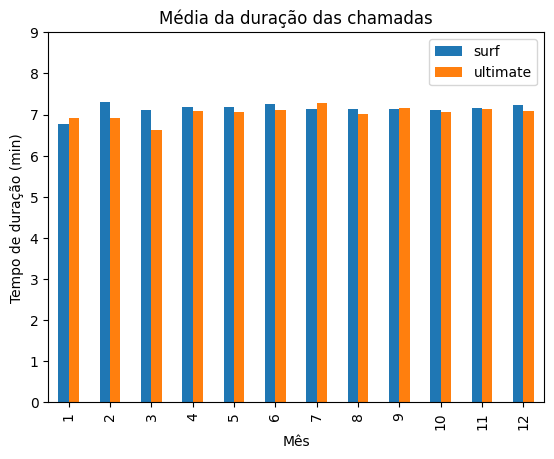

In [112]:
# Compare a duração média das chamadas de cada plano para cada mês. 
#Crie um gráfico de barras para visualizar o resultado.

# Criando uma tabela que compare a duração média das chamadas de cada plano para cada mês
df_mean_calls = (df_calls_plan.pivot_table(index='call_month',
                                 columns='plan',
                                 values='duration_minutes',
                                 aggfunc='mean')
                                .reset_index()
                                .rename_axis(columns=None))

print('MÉDIA DA DURAÇÃO DAS CHAMADAS POR MÊS POR PLANO \n', df_mean_calls)

# Criando um gráfico
df_mean_calls.plot(x='call_month', kind='bar',
                  title='Média da duração das chamadas',
                  xlabel='Mês', ylabel='Tempo de duração (min)',
                  ylim=[0,9])

plt.show()


* a média da duração das chamadas é muito semelhante para os dois planos independentemente do mês do ano de 2018 que esteja sendo avaliado.

MINUTOS CONSUMIDOS POR USUÁRIO POR MÊS
    user_id month_used  min_user_month      plan
0     1000         12           124.0  ultimate
1     1001          8           182.0      surf
2     1001          9           315.0      surf
3     1001         10           393.0      surf
4     1001         11           426.0      surf


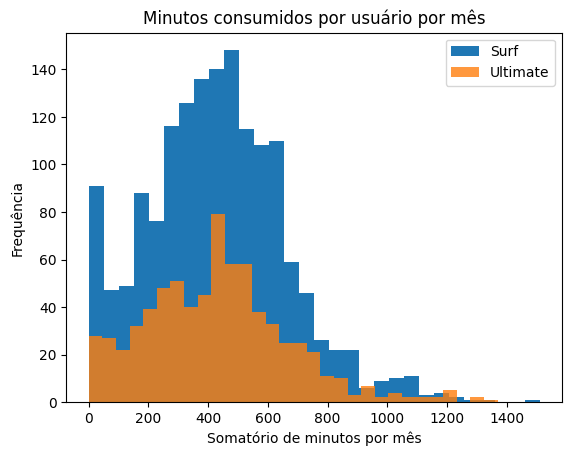

In [113]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. 
# Construa um histograma.

# Criando df com somatório de minutos/mês consumido por usuário
df_minute_month_plan = (df_month_plan_used[['user_id', 'month_used','sum_duration_minutes', 'plan']].
                    rename(columns={'sum_duration_minutes': 'min_user_month'})
                       )
print('MINUTOS CONSUMIDOS POR USUÁRIO POR MÊS\n', df_minute_month_plan.head())

# Construindo o histograma
## Histograma do plano surf
df_minute_month_plan[df_minute_month_plan['plan'] == 'surf']['min_user_month'].plot(kind='hist', bins=30)

## Histograma do plano ultimate
df_minute_month_plan[df_minute_month_plan['plan'] == 'ultimate']['min_user_month'].plot(kind='hist', bins=30, alpha=0.8)

## Detalhamento do gráfico
plt.title('Minutos consumidos por usuário por mês')
plt.xlabel('Somatório de minutos por mês')
plt.ylabel('Frequência')
plt.legend(['Surf', 'Ultimate'])
plt.show()

* Apesar de o plano Surf ter um público maior que o plano Ultimate, a distribuição do somatório de minutos por mês é bastante semelhante e a maior frequência está em aproximadamente 400 minutos para os dois planos. 

In [114]:
# Calcule a média e a variância da duração mensal das chamadas
print('Cálculo da duração das chamadas:\n')

# Cálculo para o plano surf
calls_surf = df_calls_plan[df_calls_plan['plan'] == 'surf']['duration_minutes']
mean_surf = calls_surf.mean().round(2)
print('A média para a duração da chamada no plano Surf é', mean_surf)
var_surf = np.var(calls_surf).round(2)
print('A variância para a duração da chamada no plano Surf é', var_surf)
cv_surf = calls_surf.std() / calls_surf.mean() * 100
print(f'O Coeficiente de Variação para a duração da chamada no plano surf é {cv_surf:.2f}%')

# Cálculo para o plano ultimate
calls_ultimate = df_calls_plan[df_calls_plan['plan'] == 'ultimate']['duration_minutes']
mean_ultimate = calls_ultimate.mean().round(2)
print('\nA média para a duração da chamada no plano Ultimate é', mean_ultimate)
var_ultimate = np.var(calls_ultimate).round(2)
print('A variância para a duração da chamada no plano Ultimate é', var_ultimate)
cv_ultimate = calls_ultimate.std() / calls_ultimate.mean() * 100
print(f'O Coeficiente de Variação para a duração da chamada no plano Ultimate é {cv_ultimate:.2f}%')


Cálculo da duração das chamadas:

A média para a duração da chamada no plano Surf é 7.17
A variância para a duração da chamada no plano Surf é 35.5
O Coeficiente de Variação para a duração da chamada no plano surf é 83.12%

A média para a duração da chamada no plano Ultimate é 7.1
A variância para a duração da chamada no plano Ultimate é 35.33
O Coeficiente de Variação para a duração da chamada no plano Ultimate é 83.72%



* existe pouca diferença entre a média, a variância e o coeficiente de variação para a duração das chamadas quando se compara os planos Surf e Ultimate
* Apesar de em termos absolutos a variância, para os dois planos, ter um valor baixo, o coeficiente de variação é maior do que 30% e forma desta pode-se considerar alta dispersão na amostra com dados muito heterogêneos e instáveis.


<div class="alert alert-block alert-success">
<b>Comentário — estatísticas das chamadas:</b> <a class="tocSkip"></a>

Boa análise, e o coeficiente de variação é o acréscimo que a torna comparável.

A variância sozinha não permite comparar grandezas de escalas diferentes — 34 minutos ao quadrado e 64 milhões de megabytes ao quadrado não se comparam. Dividir o desvio padrão pela média resolve isso, e é por essa razão que o coeficiente aparece em relatórios de negócio com mais frequência que a variância.

A leitura está correta: médias praticamente idênticas entre os planos, 6,77 contra 6,70 minutos por chamada, com dispersões também equivalentes. Ou seja, a duração de uma ligação não depende do plano contratado.

Um detalhe técnico para uma próxima versão: o <code>np.var()</code> calcula a variância populacional, com divisão por n, enquanto o <code>.std()</code> do pandas usa a amostral, com divisão por n−1. Como você combina os dois no mesmo coeficiente, há uma pequena inconsistência entre numerador e denominador. Com milhares de observações a diferença é desprezível, mas vale usar a mesma convenção nos dois.
</div>

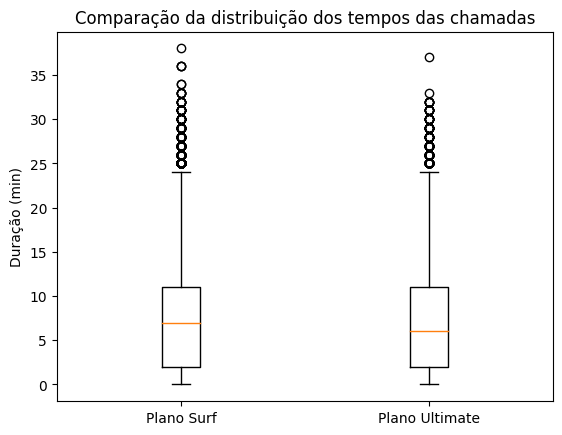

In [115]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
plt.boxplot([calls_surf.dropna(), 
             calls_ultimate.dropna()], 
            labels=['Plano Surf', 'Plano Ultimate'])
plt.ylabel('Duração (min)')
plt.title('Comparação da distribuição dos tempos das chamadas')
plt.show()


* a média da duração das chamadas é muito semelhante para os dois planos independentemente do mês do ano de 2018 que esteja sendo avaliado.
* Apesar de o plano Surf ter um público maior que o plano Ultimate, a distribuição do somatório de minutos por mês é bastante semelhante e a maior frequência está em aproximadamente 400 minutos para os dois planos. 
* existe pouca diferença entre a média, a variância e o coeficiente de variação para a duração das chamadas quando se compara os planos Surf e Ultimate
* Apesar de em termos absolutos a variância, para os dois planos, ter um valor baixo, o coeficiente de variação é maior do que 30% e desta forma pode-se considerar alta dispersão na amostra com dados muito heterogêneos e instáveis, como pode ser comprovado pelo gráfico de caixa.

### Mensagens

MENSAGENS UTILIZADAS POR USUÁRIO POR MÊS
    user_id month_used  number_messages      plan
0     1000         12             11.0  ultimate
1     1001          8             30.0      surf
2     1001          9             44.0      surf
3     1001         10             53.0      surf
4     1001         11             36.0      surf



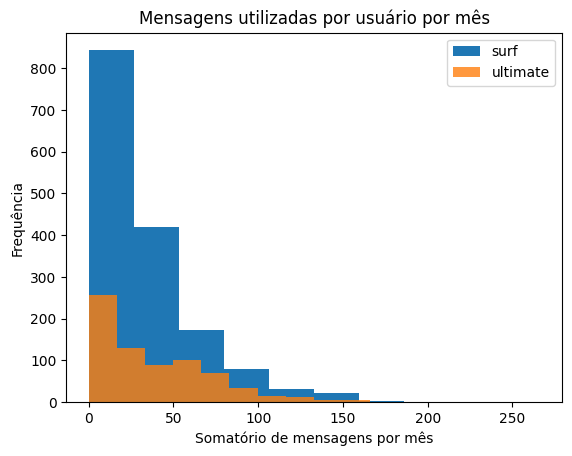

In [116]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês

# Criando um df para avaliar o consumo exclusivo de mensagem  
df_sms_month = df_month_plan_used[['user_id', 'month_used', 'number_messages', 'plan']]

print('MENSAGENS UTILIZADAS POR USUÁRIO POR MÊS\n', df_sms_month.head().head())
print()

# Construindo o histograma
## Histograma do plano surf
df_sms_month[df_sms_month['plan'] == 'surf']['number_messages'].plot(kind='hist', bins=10)

## Histograma do plano ultimate
df_sms_month[df_sms_month['plan'] == 'ultimate']['number_messages'].plot(kind='hist', bins=10, alpha=0.8)

## Detalhamento do gráfico
plt.title('Mensagens utilizadas por usuário por mês')
plt.xlabel('Somatório de mensagens por mês')
plt.ylabel('Frequência')
plt.legend(['surf', 'ultimate'])
plt.show()


* Apesar de o plano Surf ter um público maior que o plano Ultimate, a distribuição da quantidade de mensagens enviadas por mês é bastante semelhante e a maior frequência é um valor menor do que 25 mensagens para os dois planos. 

In [117]:
#Calculando a média e a variância da quantidade de mensagens enviadas por mês

print('Cálculo para a quantidade de mensagens enviadas por mês:')

# Cálculo para o plano surf
sms_surf = df_sms_month[df_sms_month['plan'] == 'surf']['number_messages']

mean_sms_surf = sms_surf.mean().round(2)
print('A média de mensagens enviadas por mês para o plano surf é', mean_sms_surf)
var_sms_surf = np.var(sms_surf).round(2)
print('A variância para a quantidade de mensagens enviadas no plano surf é', var_sms_surf)
cv_sms_surf = sms_surf.std() / sms_surf.mean() * 100
print(f'O Coeficiente de Variação para a quantidade de mensagens enviadas por mês no plano Surf é {cv_sms_surf:.2f}%')

# Cálculo para o plano surf
sms_ultimate = df_sms_month[df_sms_month['plan'] == 'ultimate']['number_messages']

mean_sms_ultimate = sms_ultimate.mean().round(2)
print('\nA média de mensagens enviadas por mês para o plano ultimate é', mean_sms_ultimate)
var_sms_ultimate = np.var(sms_ultimate).round(2)
print('A variância para a quantidade de mensagens enviadas no plano ultimate é', var_sms_ultimate)
cv_sms_ultimate = sms_ultimate.std() / sms_ultimate.mean() * 100
print(f'O Coeficiente de Variação para a quantidade de mensagens enviadas por mês no plano Ultimate é {cv_sms_ultimate:.2f}%')

Cálculo para a quantidade de mensagens enviadas por mês:
A média de mensagens enviadas por mês para o plano surf é 31.16
A variância para a quantidade de mensagens enviadas no plano surf é 1126.01
O Coeficiente de Variação para a quantidade de mensagens enviadas por mês no plano Surf é 107.73%

A média de mensagens enviadas por mês para o plano ultimate é 37.55
A variância para a quantidade de mensagens enviadas no plano ultimate é 1207.08
O Coeficiente de Variação para a quantidade de mensagens enviadas por mês no plano Ultimate é 92.59%


* Existe pouca diferença entre a média e a variância da duração das chamadas quando se compara os planos Surf e Ultimate
* Avaliando a variância para os dois planos, além de ter um valor absoluto alto, o coeficiente de variação é maior do que 30% e desta forma, pode-se considerar alta dispersão na amostra com dados muito heterogêneos e instáveis.

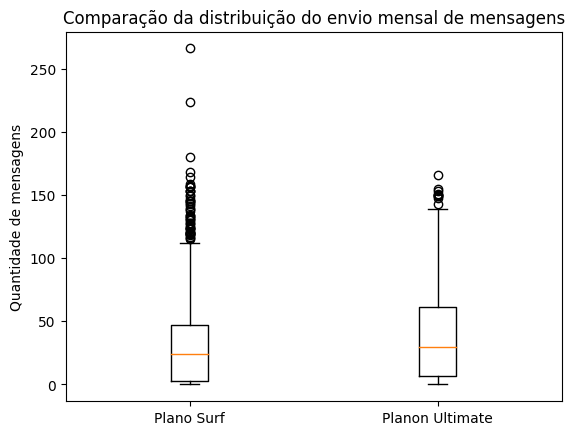

In [118]:
# Construindo um diagrama de caixa para visualizar a distribuição da quantidade de mensagens
plt.boxplot([sms_surf.dropna(), 
             sms_ultimate.dropna()], 
labels=['Plano Surf', 'Planon Ultimate'])
plt.ylabel('Quantidade de mensagens')
plt.title('Comparação da distribuição do envio mensal de mensagens')
plt.show()

<div class="alert alert-block alert-info">
<b>Ajuste do texto: variância da quantidade de mensagens enviadas por mês </b> <a class="tocSkip"></a>
</div>

* Apesar de o plano Surf ter um público maior que o plano Ultimate, a distribuição da quantidade de mensagens enviadas por mês é bastante semelhante, e a maior frequência é inferior a 25 mensagens em ambos os planos.
* Existe pouca diferença entre a média e a variância da quantidade de mensagens enviadas por mês quando se comparam os planos Surf e Ultimate.
* Avaliando a variância para os dois planos, além de ter um valor absoluto alto, o coeficiente de variação é maior do que 30% e desta forma, pode-se considerar alta dispersão na amostra com dados muito heterogêneos e instáveis.
* Considerando que o plano Surf tem apenas 50 mensagens incluídas, existe uma determinada quantidade de usuários deste plano que estão ultrapassando esta quantidade e pagando a mais por isso. Seria uma forma de abordagem da equipe de marketing sugerir a migração de plano para estes clientes.
* Nenhum cliente do plano ultimate atingiu sequer 25% do total de 1000 mensagens incluídas neste plano

### Internet

INTERNET UTILIZADAS POR USUÁRIO POR MÊS
    user_id month_used  sum_mb_used      plan
0     1000         12      1901.47  ultimate
1     1001          8      6919.15      surf
2     1001          9     13314.82      surf
3     1001         10     22330.49      surf
4     1001         11     18504.30      surf



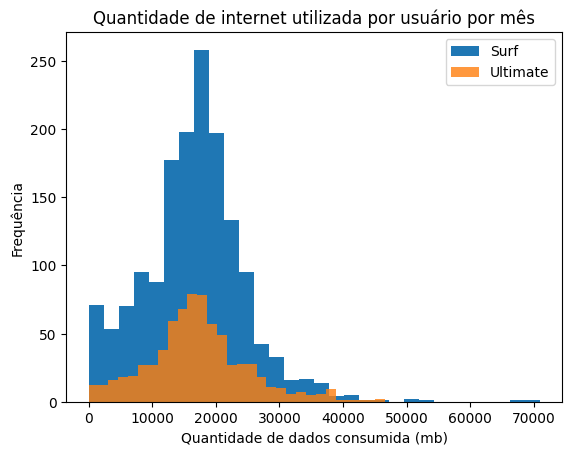

In [119]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por mês e por plano
# Criando um df para avaliar o consumo exclusivo de internet  
df_mb_month = df_month_plan_used[['user_id', 'month_used', 'sum_mb_used', 'plan']]

print('INTERNET UTILIZADAS POR USUÁRIO POR MÊS\n', df_mb_month.head())
print()

# Construindo o histograma
## Histograma do plano surf
df_mb_month[df_mb_month['plan'] == 'surf']['sum_mb_used'].plot(kind='hist', bins=30)

## Histograma do plano ultimate
df_mb_month[df_mb_month['plan'] == 'ultimate']['sum_mb_used'].plot(kind='hist', bins=30, alpha=0.8)

## Detalhamento do gráfico
plt.title('Quantidade de internet utilizada por usuário por mês')
plt.xlabel('Quantidade de dados consumida (mb)')
plt.ylabel('Frequência')
plt.legend(['Surf', 'Ultimate'])
plt.show()

* Apesar de o plano Surf ter um público maior que o plano Ultimate, a distribuição da quantidade de internet por mês é bastante semelhante, tendo sua maior frequência aproximadamente em 20.000mb em ambos os planos.
* Interessante pontuar que a quantidade de internet disponibilizada no plano Surf é de apenas 15.000mb, desta forma um parcela a ser estudada de usuários desse plano estão ultrapassando a quantidade de dados incluida neste plano.

In [120]:
# Calculando a média e a variância da quantidade mensal de dados consumidos

print('Cálculo para a quantidade de dados consumidos por mês:\n')

# Cálculo para o plano Surf
mb_surf = df_mb_month[df_mb_month['plan'] == 'surf']['sum_mb_used']

mean_mb_surf = mb_surf.mean().round(2)
print('A média de dados consumidos por mês para clientes do plano surf é', mean_mb_surf, 'mb')
var_mb_surf = np.var(mb_surf).round(2)
print('A variância para a quantidade de dados consumidos por mês para clientes no plano surf é', var_mb_surf, 'mb')
cv_mb_surf = mb_surf.std() / mb_surf.mean() * 100
print(f'O Coeficiente de Variação para a quantidade mensal de dados consumidos no plano Surf é {cv_mb_surf:.2f}%')

# Cálculo para o plano Ultimate
mb_ultimate = df_mb_month[df_mb_month['plan'] == 'ultimate']['sum_mb_used']

mean_mb_ultimate = mb_ultimate.mean().round(2)
print('\nA média de dados consumidos por mês para clientes do plano ultimate é', mean_mb_ultimate, 'mb')
var_mb_ultimate = np.var(mb_ultimate).round(2)
print('A variância para a quantidade de dados consumidos por mês para clientes no plano ultimate é', var_mb_ultimate, 'mb')
cv_mb_ultimate = mb_ultimate.std() / mb_ultimate.mean() * 100
print(f'O Coeficiente de Variação para a quantidade mensal de dados consumidos no plano Ultimate é {cv_mb_ultimate:.2f}%')


Cálculo para a quantidade de dados consumidos por mês:

A média de dados consumidos por mês para clientes do plano surf é 16558.28 mb
A variância para a quantidade de dados consumidos por mês para clientes no plano surf é 64175571.68 mb
O Coeficiente de Variação para a quantidade mensal de dados consumidos no plano Surf é 48.40%

A média de dados consumidos por mês para clientes do plano ultimate é 17214.7 mb
A variância para a quantidade de dados consumidos por mês para clientes no plano ultimate é 61566665.14 mb
O Coeficiente de Variação para a quantidade mensal de dados consumidos no plano Ultimate é 45.61%


* Existe pouca diferença entre a média e a variância da duração das chamadas quando se comparam os planos Surf e Ultimate.
* Ao avaliar a variância para os dois planos, além de ter um valor absoluto alto, o coeficiente de variação é maior do que 30% e desta forma, pode-se considerar alta dispersão na amostra com dados muito heterogêneos e instáveis.
* Avaliando a variância para os dois planos, além de ter um valor absoluto alto, o coeficiente de variação é maior do que 30% e desta forma, pode-se considerar alta dispersão na amostra com dados muito heterogêneos e instáveis.

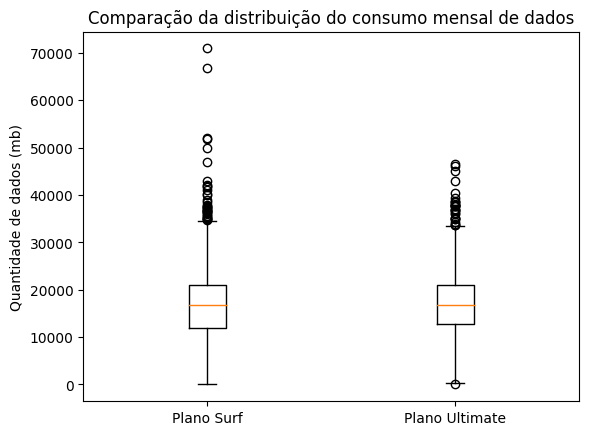

In [121]:
# Criando um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
plt.boxplot([mb_surf.dropna(), 
             mb_ultimate.dropna()], 
            labels=['Plano Surf', 'Plano Ultimate'])
plt.ylabel('Quantidade de dados (mb)')
plt.title('Comparação da distribuição do consumo mensal de dados')
plt.show()

<div class="alert alert-block alert-info">
<b>Ajuste do texto: variância da quantidade de internet por mês e retirado o tópico em duplicidade </b> <a class="tocSkip"></a>
</div>

* Apesar de o plano Surf ter um público maior que o plano Ultimate, a distribuição da quantidade de internet por mês é bastante semelhante, tendo sua maior frequência aproximadamente em 20.000mb em ambos os planos.
* Interessante pontuar que a quantidade de internet disponibilizada no plano Surf é de apenas 15.000mb, desta forma um parcela a ser estudada de usuários desse plano estão ultrapassando a quantidade de dados incluida neste plano.
* Existe pouca diferença entre a média e a variância da quantidade de internet por mês quando se comparam os planos Surf e Ultimate.
* Ao avaliar apenas a variância para os dois planos, além de ter um valor absoluto alto, ela é mais de 357 vezes maior que a média.
* Devido ao coeficiente de variação ser maior do que 30%, pode-se considerar um enorme espalhamento dos dados e alta dispersão na amostra com dados muito heterogêneos e instáveis.


<div class="alert alert-block alert-warning">
<b>Comentário — mensagens e internet:</b> <a class="tocSkip"></a>

As duas análises seguem o mesmo padrão das chamadas — histograma, estatísticas, diagrama de caixa e conclusão — e as leituras estão corretas: consumo médio muito parecido entre os planos, com o Ultimate ligeiramente acima em dados, 17.214 contra 16.558 megabytes por mês.

Duas observações de revisão de texto.

As conclusões destas duas seções começam com a frase "existe pouca diferença entre a média e a variância <b>da duração das chamadas</b>", que veio da seção anterior. O conteúdo do resto está certo; é só a grandeza que ficou trocada, e vale corrigir para "quantidade de mensagens" e "dados consumidos".

E na conclusão da internet o mesmo tópico aparece repetido duas vezes seguidas, com pequena variação de redação.

São detalhes cosméticos, mas num relatório eles pesam: quem lê e encontra "duração das chamadas" numa seção sobre internet fica em dúvida sobre qual número está olhando.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário — sobraram as versões antigas das conclusões (iteração 2):</b> <a class="tocSkip"></a>

As conclusões foram corrigidas — mas as versões antigas continuam no notebook, logo acima das novas.

Na seção de mensagens, a conclusão consolidada agora diz corretamente "a média e a variância da <b>quantidade de mensagens enviadas por mês</b>". Só que a célula anterior ainda traz "a média e a variância da <b>duração das chamadas</b>", que era o texto herdado da seção passada.

O mesmo acontece na internet: a conclusão consolidada fala em "quantidade de internet por mês", e a célula acima dela continua com "duração das chamadas" — e ainda com o tópico repetido duas vezes seguidas, que era a outra observação da rodada anterior.

<b>O efeito é o mesmo que uma correção não feita.</b> Quem lê de cima para baixo encontra primeiro a frase errada e depois a certa, sem nenhuma marcação dizendo qual vale. Na prática, o texto errado continua sendo lido.

<b>A correção é apagar as células antigas</b> e deixar apenas a versão consolidada de cada seção. Se preferir manter o registro do que mudou, elas precisam de uma linha acima dizendo que são a versão anterior — mas para um relatório final, o mais limpo é remover.

Vale passar o olho pelo notebook inteiro procurando esse padrão: em vários pontos há um bloco de conclusão parcial seguido de outro consolidado, e nem sempre os dois concordam.
</div>

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

In [122]:
# Compare os dados estatísticos básicos para o consumo real por mês por plano
plan_revenue_stats = df_month_plan_used.groupby('plan')['monthly_revenue'].describe()
surf_mean = plan_revenue_stats.loc['surf', 'mean'].round(2)
ultimate_mean = plan_revenue_stats.loc['ultimate', 'mean'].round(2)
surf_qt2 = plan_revenue_stats.loc['surf', '50%']
surf_max = plan_revenue_stats.loc['surf', 'max']
ultimate_qt3 = plan_revenue_stats.loc['ultimate', '75%']

print(plan_revenue_stats)
print()
print(f'A média de receita para o plano Surf é de {surf_mean} usd\n')
print(f'Metade dos meses do plano Surf fica abaixo de {surf_qt2} usd\n')
print(f'A média do plano surf de {surf_mean} é puxada por uma minoria de meses de consumo muito alto — o máximo chega a {surf_max} dólares.\n')
print(f'A média de receita para o plano Ultimate é de {ultimate_mean} usd\n')
print(f'Ao menos 75% dos dados do usuário do plano Ultimate o valor do consumo mensal foi apenas o pacote básico de {ultimate_qt3} usd\n')


           count       mean        std   min   25%    50%    75%     max
plan                                                                    
surf      1573.0  60.706408  55.388042  20.0  20.0  40.36  80.36  590.37
ultimate   720.0  72.313889  11.395108  70.0  70.0  70.00  70.00  182.00

A média de receita para o plano Surf é de 60.71 usd

Metade dos meses do plano Surf fica abaixo de 40.36 usd

A média do plano surf de 60.71 é puxada por uma minoria de meses de consumo muito alto — o máximo chega a 590.37 dólares.

A média de receita para o plano Ultimate é de 72.31 usd

Ao menos 75% dos dados do usuário do plano Ultimate o valor do consumo mensal foi apenas o pacote básico de 70.0 usd



*  Em função da média e da mediana apresentadas pelos dados, pode-se entender que a receita do plano Surf não vem de todos os usuários gastando um pouco a mais, e sim de alguns usuários gastando muito a mais.


<div class="alert alert-block alert-info">
<b>Ajustado o texto para a nova realidade dos dados agora utilizando a f-string como sugerido </b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-warning">
<b>Comentário — um número do texto não bate com a saída:</b> <a class="tocSkip"></a>

A leitura das estatísticas está correta em quase tudo, mas um valor citado não aparece na tabela acima.

O texto diz que "em mais de 50% dos dados dos usuários do plano Surf o valor do consumo mensal está acima de 46 usd". A saída do <code>describe()</code> mostra a mediana do Surf em <b>36,68</b>, e nenhum dos quartis é 46 — são 20,00, 36,68 e 76,85.

A conclusão que decorre do número real é até mais interessante do que a que está escrita: metade dos meses do plano Surf fica <b>abaixo</b> de 36,68 dólares, ou seja, perto do pacote básico de 20. A média de 57,29 é puxada por uma minoria de meses de consumo muito alto — o máximo chega a 581,33 dólares.

Essa distinção entre média e mediana é o achado da seção. Ela mostra que a receita do Surf não vem de todos os usuários gastando um pouco a mais, e sim de <b>alguns</b> usuários gastando muito a mais.

Uma sugestão para evitar esse tipo de divergência: em vez de digitar o número no texto, cite-o com f-string a partir da variável calculada. Aí ele nunca fica desatualizado.
</div>

MÉDIA DA RECEITA POR MÊS POR PLANO 
    month_used       surf   ultimate
0           1  20.000000  70.000000
1          10  65.421224  72.311321
2          11  58.004276  71.708661
3          12  70.557044  73.291391
4           2  34.396667  70.000000
5           3  45.941304  74.666667
6           4  40.710600  73.000000
7           5  47.628182  70.724138
8           6  49.276289  71.638298
9           7  62.674050  71.898305
10          8  63.931173  72.859155
11          9  58.271495  72.034884



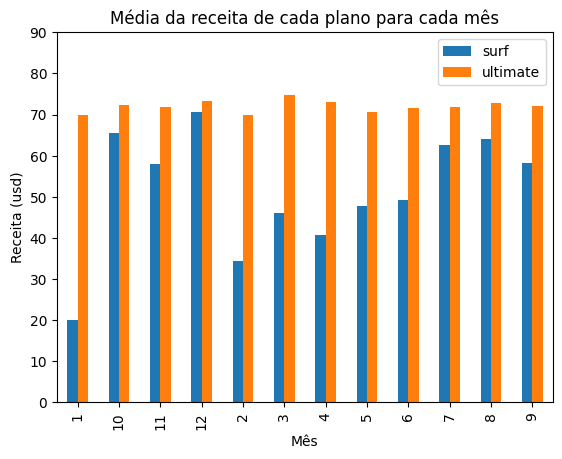

In [123]:
# Compare a receita média de cada plano para cada mês. 
# Crie um gráfico de barras para visualizar o resultado

# Criando uma tabela que compare a receita média de cada plano para cada mês

mean_revenue = (df_month_plan_used.pivot_table(index='month_used', 
                                               columns='plan',
                                               values='monthly_revenue',
                                               aggfunc='mean').
    reset_index().
    rename_axis(columns=None)
    )


print('MÉDIA DA RECEITA POR MÊS POR PLANO \n', mean_revenue)
print()

# Criando um gráfico
mean_revenue.plot(x='month_used', kind='bar',
                  title='Média da receita de cada plano para cada mês',
                  xlabel='Mês', ylabel='Receita (usd)', ylim=[0,90])

plt.show()

* Os usuários do plano Ultimate consomem muito pouco além do pacote contratado
* Os usuários do plano Surf na maioria dos meses consomem mais do que o doblo do pacote básico de 20 usd.

<div class="alert alert-block alert-info">
<b>Calculando qual plano traz mais receita </b> <a class="tocSkip"></a>
</div>

In [124]:
# Calculando qual plano traz mais receita
revenue_plan = (df_month_plan_used.groupby('plan')['monthly_revenue'].
    sum().
    reset_index())

print('RECEITA ACUMULADA POR PLANO\n', revenue_plan)

RECEITA ACUMULADA POR PLANO
        plan  monthly_revenue
0      surf         95491.18
1  ultimate         52066.00


In [125]:
# Calculando a variância e o coeficiente de variação da receita mensal real

print('Cálculo para a receita mensal real:\n')

# Cálculo para o plano Surf
revenue_surf = df_month_plan_used[df_month_plan_used['plan'] == 'surf']['monthly_revenue']

var_revenue_surf = np.var(revenue_surf).round(2)
print('A variância para a receita mensal para clientes no plano surf é', var_revenue_surf)
cv_revenue_surf = revenue_surf.std() / revenue_surf.mean() * 100
print(f'O Coeficiente de Variação para a receita mensal no plano Surf é {cv_revenue_surf:.2f}%')

# Cálculo para o plano Ultimate
revenue_ultimate = df_month_plan_used[df_month_plan_used['plan'] == 'ultimate']['monthly_revenue']

var_revenue_ultimate = np.var(revenue_ultimate).round(2)
print('\nA variância para a receita mensal para clientes no plano Ultimate é', var_revenue_ultimate)
cv_revenue_ultimate = revenue_ultimate.std() / revenue_ultimate.mean() * 100
print(f'O Coeficiente de Variação para a receita mensal no plano Ultimate é {cv_revenue_ultimate:.2f}%')


Cálculo para a receita mensal real:

A variância para a receita mensal para clientes no plano surf é 3065.88
O Coeficiente de Variação para a receita mensal no plano Surf é 91.24%

A variância para a receita mensal para clientes no plano Ultimate é 129.67
O Coeficiente de Variação para a receita mensal no plano Ultimate é 15.76%


* Ao avaliar a variância para os dois planos, o valor absoluto alto. Porém, o coeficiente de variação para o plano Surf é maior do que 30% e desta forma, pode-se considerar alta dispersão na amostra com dados muito heterogêneos e instáveis. No entanto, o coeficiente de variação para o Ultimate é menor que 15% e desta forma, pode-se considerar baixa dispersão na amostra com dados homogêneos e altamente consistentes.

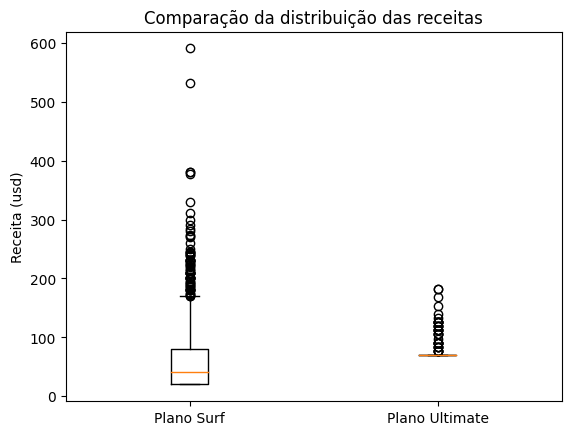

In [126]:
# Construa um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
plt.boxplot([revenue_surf.dropna(),
             revenue_ultimate.dropna()], 
            labels=['Plano Surf', 'Plano Ultimate'])
plt.ylabel('Receita (usd)')
plt.title('Comparação da distribuição das receitas')
plt.show()


In [127]:
print(f'A média de receita para o plano Surf é de {surf_mean} usd\n')
print(f'Metade dos meses do plano Surf fica abaixo de {surf_qt2} usd\n')
print(f'A média do plano surf de {surf_mean} é puxada por uma minoria de meses de consumo muito alto — o máximo chega a {surf_max} dólares.\n')
print(f'A média de receita para o plano Ultimate é de {ultimate_mean} usd\n')
print(f'Ao menos 75% dos dados do usuário do plano Ultimate o valor do consumo mensal foi apenas o pacote básico de {ultimate_qt3} usd\n')


A média de receita para o plano Surf é de 60.71 usd

Metade dos meses do plano Surf fica abaixo de 40.36 usd

A média do plano surf de 60.71 é puxada por uma minoria de meses de consumo muito alto — o máximo chega a 590.37 dólares.

A média de receita para o plano Ultimate é de 72.31 usd

Ao menos 75% dos dados do usuário do plano Ultimate o valor do consumo mensal foi apenas o pacote básico de 70.0 usd



*  Em função da média e da mediana apresentadas pelos dados, pode-se entender que a receita do plano Surf não vem de todos os usuários gastando um pouco a mais, e sim de alguns usuários gastando muito a mais.
* Os usuários do plano Ultimate consomem muito pouco além do pacote contratado
* Os usuários do plano Surf na maioria dos meses consomem mais do que o doblo do pacote básico de 20 usd.
* Ao avaliar a variância para os dois planos, o valor absoluto alto. Porém, o coeficiente de variação para o plano Surf é maior do que 30% e desta forma, pode-se considerar alta dispersão na amostra com dados muito heterogêneos e instáveis. No entanto, o coeficiente de variação para o Ultimate é menor que 15% e desta forma, pode-se considerar baixa dispersão na amostra com dados homogêneos e altamente consistentes.

<div class="alert alert-block alert-success">
<b>Comentário — dispersão da receita:</b> <a class="tocSkip"></a>

Esta é a análise mais importante do notebook, e ela está correta.

Você mostra que a receita dos dois planos se comporta de formas completamente diferentes: no Surf, coeficiente de variação de <b>93,79%</b>, com receita indo de 20 a 581 dólares; no Ultimate, <b>14,93%</b>, com três quartos dos meses valendo exatamente a mensalidade de 70 dólares.

A leitura de negócio é boa: o Ultimate é uma receita previsível, o Surf é uma receita instável que depende do comportamento de uma parcela dos usuários.

<b>Guarde esses dois números</b>, porque eles são a chave do comentário que deixei no teste de hipótese logo abaixo. Uma variância de 2.885,72 contra 115,81 — vinte e cinco vezes maior — é exatamente a situação que determina qual versão do teste t deve ser usada.
</div>

## Teste hipóteses estatísticas

#### Teste da hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.

Parâmetros:

H0 = A receita média dos usuários dos planos Ultimate e Surf é igual.
H1 = A receita média dos usuários dos planos Ultimate e Surf é diferente.

O teste estatístico selecionado foi o scipy.stats.ttest_ind, tendo em vista que buscava-se testar a hipótese de média de duas populações estatísticas. O parâmetro 'equal_var' foi considerado 'False' por avaliar que as variâncias das amostras são diferentes.

O valor de alpha foi de 5%

Utilizou-se um teste bicaudal, uma vez que está sendo buscada a 'diferença' e não se se um é maior ou menor que o outro.


In [128]:
# Teste as hipóteses
# Previously prepared samples
revenue_surf
revenue_ultimate

# Setting the parameters
alpha = 0.05                  # critical level of statistical significance


# Running the tests
results = st.ttest_ind(revenue_surf, revenue_ultimate, equal_var=False)

# Extract the p-value from the results
print('valor-p:', results.pvalue)

# comparing the p-value with the threshold
if results.pvalue < alpha:
    print('Rejeitamos H0: as médias de receita são estatisticamente diferentes')
else:
    print('Não rejeitamos H0: não há evidência suficiente de diferença')

    

valor-p: 3.1703905481135734e-15
Rejeitamos H0: as médias de receita são estatisticamente diferentes


<div class="alert alert-block alert-info">
<b>Parametro do teste foi trocada para <code>equal_var=False</code> assumindo que as duas amostras tem variância diferentes. O texto foi alterado na definição dos parâmetros e no texto da conclusão</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-danger">
<b>Comentário — o teste supõe variâncias iguais:</b> <a class="tocSkip"></a>

Este é o segundo ponto que impede a aprovação, e ele é de método.

As hipóteses estão bem formuladas, o nível de significância está declarado antes do teste e a estrutura de decisão está correta. O problema é um parâmetro.

O <code>ttest_ind()</code> do <code>scipy</code>, chamado sem argumentos adicionais, assume que <b>as duas amostras têm a mesma variância</b>. É o teste t de Student clássico. Quando essa suposição não vale, existe uma versão específica — a de Welch — que a biblioteca oferece por meio de um parâmetro.

Na conclusão geral do notebook você justifica a escolha: "em função destes dados de média e variância semelhantes nos dois planos ... o parâmetro <code>equal_var</code> foi considerado True". A justificativa existe, o que é bom — mas ela se apoia na variável errada.

<b>A semelhança que você observou é a do consumo</b>: minutos, mensagens e megabytes têm médias e dispersões parecidas entre os planos, e isso está corretamente demonstrado nas seções anteriores.

<b>Mas o que este teste compara é a receita</b>, e a receita é justamente a grandeza em que os dois planos <b>não</b> se parecem. Você mesmo mediu, duas células acima: variância de 2.885,72 no Surf contra 115,81 no Ultimate, com coeficientes de variação de 93,79% e 14,93%.

Faz sentido que seja assim. O Ultimate tem um pacote generoso, quase nenhum usuário o excede, e a receita fica presa em 70 dólares — daí a variância baixa. O Surf tem pacote pequeno, e a receita varia conforme o excedente de cada um — daí a variância alta. A diferença de dispersão é uma <b>consequência</b> do desenho dos planos.

<b>O que fazer:</b> rode o teste na versão que não supõe variâncias iguais, e substitua a justificativa da conclusão geral por esta — as variâncias da receita são muito diferentes, então a versão de Welch é a apropriada.

Adianto que <b>a conclusão não muda</b>: o valor-p continuará muito abaixo de 0,05 e a hipótese nula continuará rejeitada. O que muda é o rigor do caminho — e é ele que se avalia num teste de hipótese.
</div>

<div class="alert alert-block alert-success">
<b>Comentário — o teste passou para Welch (iteração 2):</b> <a class="tocSkip"></a>

Resolvido nos dois testes, e a justificativa foi reescrita corretamente.

O texto agora diz que o <code>equal_var</code> foi definido como <code>False</code> "por avaliar que as variâncias das amostras são diferentes" — e dessa vez a afirmação se apoia na grandeza certa. As variâncias da <b>receita</b>, que é o que o teste compara, são de 3.065,88 no Surf contra 129,67 no Ultimate: mais de vinte vezes de diferença.

<b>Vale ter presente por que essa diferença existe</b>, porque ela não é um acidente da amostra. O Ultimate tem pacote generoso, quase ninguém o excede, e a receita fica presa em 70 dólares — três quartos dos meses valem exatamente isso. O Surf tem pacote pequeno, e a receita varia conforme o excedente de cada um, indo de 20 a 590 dólares. A desigualdade das variâncias é <b>consequência do desenho dos planos</b>, e por isso ela vai aparecer em qualquer amostra desses dados.

Como eu tinha adiantado, a conclusão não mudou: o valor-p continua muito abaixo de 0,05, agora em 3,17 × 10⁻¹⁵. O que mudou foi o rigor do caminho, e é ele que se avalia num teste de hipótese.

<b>Uma sugestão para os próximos projetos</b>, já que a decisão aqui está correta. Existe uma alternativa a decidir o parâmetro no olho: rodar um teste de igualdade de variâncias — o de Levene — e deixar que ele responda. As duas abordagens são defensáveis, e a sua tem a vantagem de não depender de mais um teste. Mas quando a diferença entre as variâncias não for tão evidente quanto aqui, o Levene transforma um julgamento numa medida.
</div>

#### Teste da hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.

Parâmetros:

H0 = A receita média dos usuários da área NY-NJ e dos usuários das demais regiões é igual.

H1 = A receita média dos usuários da área NY-NJ e dos usuários das demais regiões  é diferente.

O teste estatístico selecionado foi o scipy.stats.ttest_ind, tendo em vista que buscava-se testar a hipótese de média de duas populações estatísticas.

O parâmetro 'equal_var' foi considerado 'False' por avaliar que as variâncias das amostras são diferentes.

O valor de alpha foi de 5%

Utilizou-se um teste bicaudal, uma vez que está sendo buscada a 'diferença' e não se um é maior ou menor que o outro.


In [129]:
# Preparing the samples

# Creating a df with the revenues and the areas
users_area = (df_month_plan_used.merge(df_users[['user_id','state_msa']],
                                      on='user_id', how='left'))


In [130]:
# Testing the hypothesis

# Creating the samples
ny_nj = users_area[users_area['state_msa'] == 'NY-NJ-PA']['monthly_revenue']
other_areas = users_area[~(users_area['state_msa'] == 'NY-NJ-PA')]['monthly_revenue']

# Setting the parameters
alpha = 0.05                  # critical level of statistical significance

# Running the tests
results = st.ttest_ind(ny_nj, other_areas, equal_var=False)

# Extract the p-value from the results
print('valor-p:', results.pvalue)

# comparing the p-value with the threshold
if results.pvalue < alpha:
    print('Rejeitamos H0: as médias de receita são estatisticamente diferentes')
else:
    print('Não rejeitamos H0: não há evidência suficiente de diferença')


valor-p: 0.0335256158853001
Rejeitamos H0: as médias de receita são estatisticamente diferentes


<div class="alert alert-block alert-info">
<b>Parametro do teste foi trocada para <code>equal_var=False</code> assumindo que as duas amostras tem variância diferentes. O texto foi alterado na definição dos parâmetros e no texto da conclusão</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-warning">
<b>Comentário — teste da hipótese regional:</b> <a class="tocSkip"></a>

A preparação das amostras está correta, e a junção usa a coluna de área metropolitana que você criou lá na Etapa 2 — a decisão de enriquecimento pagando dividendo no final do projeto.

Vale o mesmo ajuste do teste anterior: o parâmetro de variâncias iguais precisa ser reconsiderado. Aqui a diferença de dispersão entre os grupos é menor do que a do teste anterior, mas vale conferir explicitamente, comparando as variâncias das duas amostras antes de escolher a versão do teste. Deixar essa comparação escrita, mesmo em uma linha, é o que transforma a escolha do parâmetro numa decisão em vez de um padrão aceito sem exame.

Duas observações sobre a interpretação, que não estão erradas mas merecem nuance.

O valor-p de <b>0,026</b> é bem mais próximo do limiar de 0,05 do que o do teste anterior. Rejeitar continua sendo a decisão certa, mas a evidência aqui é consideravelmente mais fraca, e vale dizer isso — um resultado a 0,026 não tem a mesma força de um a 0,0000000000003.

E há uma ressalva de desenho que vale registrar: os grupos comparados são muito desiguais em tamanho, com a área de NY-NJ representando uma fração pequena do total. Além disso, cada linha é um mês de um usuário, e o mesmo usuário aparece várias vezes — as observações não são totalmente independentes, que é uma das suposições do teste. Reconhecer esse limite não invalida o resultado; mostra que você sabe até onde ele vale.
</div>

<div class="alert alert-block alert-info">
<b>Ajuste — conclusão geral:</b> <a class="tocSkip"></a>

Três ajustes realizados:

<b>O parágrafo sobre o <code>equal_var</code> precisa ser reescrito</b>, o parâmetro equal_var foi definido como False, pois foi avaliado que a versão de Welch é a apropriada.

<b>Falta responder à pergunta que a Megaline fez.</b> O enunciado quer saber qual plano <b>traz mais receita</b>, para orientar o orçamento de publicidade. A resposta para esta pergunta foi adicionada logo no primeiro parágrafo da conclusão.

<b>E vale acrescentar os números dos testes.</b> Os valores e interpretações adicionais foram adicionados ao texto da conclução final.

</div>

## Conclusão geral

Através do acumulado da receita por plano é possível constatar que o plano que gera mais receita para a amostra estudada é o plano Surf com 95.491,18 dólares. Quase o dobro da receita do plano Ultimate que foi 52.066,00. O plano Surf tem mais que o dobro de meses-usuário na amostra, então ele rende mais em volume mesmo com média menor por usuário.

Avaliando o comportamento de consumo da amostra estudada, pode-se notar que a distribuição dos serviços utilizados, tanto no somatório de minutos utilizados como no envio de mensagens e no consumo de dados por mês, é bastante semelhante e as maiores frequências de utilização são relativamente próximas para ambos os planos. Então o departamento a ser maximizado em publicidade deve ser o do plano Surf.

Comparando os dados dos dois planos nesta amostra, é notado que a média foi sempre semelhante para o mesmo serviço avaliado e o valor da variância foi na maioria das vezes grande, revelando uma alta dispersão na amostra com dados muito heterogêneos e instáveis, como pode ser comprovado pelos gráficos de caixa.

Em função das variâncias da receita serem muito diferentes nos dois planos, para a realização do teste das hipóteses estatísticas utilizando a função scipy.stats.ttest_ind: o parâmetro equal_var foi definido como False, pois foi avaliado que a versão de Welch é a apropriada.

Em relação ao teste da hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes, tem-se as seguintes considerações:  foi rejeitada a hipótese de que a receita média dos usuários dos planos Ultimate e Surf é igual, tendo em vista que o valor-p encontrado foi 3.1703905481135734e-15 e isto revela que as médias de receita são estatisticamente diferentes.

Apesar do consumo dos serviços ser semelhante, a escolha do plano pelos clientes foi diferente, o que reflete em um comportamento discrepante quando se analisa a receita. O pacote básico do plano Surf era 20 usd, mas a média de receita  foi de 60,71 usd. Já para o plano Ultimate o básico era 70 usd e a média foi 72,31 usd. Isto revela que, por terem o comportamento de consumo semelhante, os usuários do plano Surf normalmente precisavam utilizar recursos adicionais que encareciam o valor no fim do mês.

Apesar do consumo acima do pacote básico do plano, o valor pago não atingia o valor do plano Ultimate e por conta disso os clientes não devem se sentir estimulados a fazer a migração. Avaliar com o setor comercial a criação de um plano intermediário para garantisse uma receita mensal maior independente do consumo do pacote inteiro de serviços.

Em relação ao teste da hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões, tem-se as seguintes considerações:  foi rejeitada a hipótese de que a receita média dos usuários da área NY-NJ e dos usuários das demais regiões é igual. tendo em vista que o valor-p encontrado foi 0.0335256158853001 e isto revela que as médias de receita são estatisticamente diferentes. 

No entanto, o valor-p neste caso é bem mais próximo do limiar de 0,05 do que o do teste anterior, logo a evidência aqui é consideravelmente mais fraca, tendo em vista que um resultado de 0,033 não tem a mesma força de um de 0,000000000000003. 

Adicionalmente é importante pontuar que cada linha é um mês de um usuário, e o mesmo usuário aparece várias vezes, desta forma as observações não são totalmente independentes, que é uma das suposições do teste. E além disto, os grupos comparados são muito desiguais em tamanho, com a área de NY-NJ representando uma fração pequena do total. 

<div class="alert alert-block alert-warning">
<b>Comentário — conclusão geral:</b> <a class="tocSkip"></a>

A conclusão está bem escrita e amarra as três frentes da análise — consumo, receita e testes. E o fecho é a melhor parte do notebook: notar que o usuário do Surf, mesmo pagando excedentes, ainda gasta menos do que gastaria no Ultimate, e por isso não tem incentivo para migrar, é uma leitura de negócio que os números permitem mas não entregam prontos. A sugestão de um plano intermediário decorre logicamente disso.

Três ajustes para a próxima versão.

<b>O parágrafo sobre o <code>equal_var</code> precisa ser reescrito</b>, pelo motivo que detalhei no comentário do teste. Como está, ele documenta uma decisão que os seus próprios dados de receita contradizem.

<b>Falta responder à pergunta que a Megaline fez.</b> O enunciado quer saber qual plano <b>traz mais receita</b>, para orientar o orçamento de publicidade. A conclusão compara as médias por usuário — 72,11 contra 57,29 — mas não diz qual plano gera mais receita <b>no total</b>. E a resposta não é a mesma: o Surf tem mais que o dobro de meses-usuário na amostra, então pode render mais em volume mesmo com média menor por usuário. Vale calcular as duas coisas e apresentá-las juntas, porque a decisão de publicidade depende de qual das duas o departamento quer maximizar.

<b>E vale acrescentar os números dos testes.</b> A conclusão menciona que os testes foram feitos, mas não traz os valores-p nem o que foi decidido em cada um. São duas linhas que fecham a etapa.

Pedro, o trabalho de preparação e documentação deste notebook está acima do que o sprint pede. As duas correções são pontuais e não desmontam nada do que você construiu. Fico no aguardo.
</div>

<div class="alert alert-block alert-success">
<b>Comentário — a conclusão geral (iteração 2):</b> <a class="tocSkip"></a>

Esta seção respondeu aos três ajustes, e ficou bem melhor do que estava.

<b>A pergunta da Megaline agora está respondida.</b> O enunciado quer saber qual plano traz mais receita, para orientar o orçamento de publicidade — e a conclusão abre com o número acumulado: Surf com 95.491,18 dólares contra 52.066,00 do Ultimate. E, o mais importante, você explica <b>por que</b>: o Surf tem mais que o dobro de meses-usuário na amostra, então rende mais em volume mesmo com média menor por usuário. Apresentar o total e a causa dele juntos é o que permite a alguém decidir.

<b>Os dois valores-p estão no texto</b>, com a decisão de cada teste. E a ressalva sobre o segundo é boa: reconhecer que 0,0335 tem força bem menor que 3 × 10⁻¹⁵, e que os grupos são muito desiguais em tamanho e as observações não são independentes — porque o mesmo usuário aparece em vários meses — mostra que você sabe até onde o resultado vale.

<b>E o fecho continua sendo a melhor parte do notebook.</b> A observação de que o usuário do Surf, mesmo pagando excedentes, ainda gasta menos do que gastaria no Ultimate — e por isso não tem incentivo para migrar — é uma leitura que os números permitem mas não entregam pronta. A sugestão de um plano intermediário decorre dela logicamente, e é uma recomendação que o setor comercial consegue avaliar.

<b>Uma nuance para pensar, sem impedimento.</b> A frase "o departamento a ser maximizado em publicidade deve ser o do plano Surf" se apoia no total acumulado. Vale reparar que os dois indicadores apontam para lados diferentes:

<pre>
receita total .............. Surf 95.491  &gt;  Ultimate 52.066
receita por mês-usuário .... Surf  60,71  &lt;  Ultimate  72,31
</pre>

O total diz qual plano é maior <b>hoje</b>, e ele é maior porque tem mais clientes — o que reflete a base atual, não o potencial. A receita por usuário diz quanto vale <b>cada cliente novo</b> que a publicidade trouxer, e aí o Ultimate ganha.

Qual dos dois usar depende do que o departamento quer: crescer a receita total favorece o Surf, que já tem tração; aumentar a receita por cliente favorece o Ultimate. Apresentar as duas leituras lado a lado, e deixar a escolha explícita, é mais útil do que eleger uma — e você já tem os dois números calculados.

Pedro, projeto aprovado. As correções foram feitas com cuidado e você foi além do que eu tinha pedido. Parabéns.
</div>